# Employee Attrition Prediction using Artificial Neural Networks (ANN)

**Dataset:** IBM HR Analytics Employee Attrition & Performance  
**Target:** `Attrition` (`No = 0`, `Yes = 1`)

## Project Flow
1. Import Libraries
2. Load Dataset
3. Explore Dataset
4. Data Cleaning
5. Exploratory Data Analysis
6. Data Preprocessing
7. Train/Test Split
8. Feature Scaling
9. Baseline ANN
10. ANN Experimentation
11. Overfitting Analysis
12. Regularization
13. Class Imbalance
14. Final Class-Weighted ANN
15. Final Evaluation
16. Model Comparison
17. Final Conclusion
18. Save Final Model

## 1. Import Libraries

In [164]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 2. Load Dataset

In [165]:
# Change the filename/path if required
## load the data set 
file_path=r"D:\spyderProject\deep learning\Employee_Attrition_ANN\data\WA_Fn-UseC_-HR-Employee-Attrition.csv"
df=pd.read_csv(file_path)

print('dataset has loaded successfully ')
print('dataset shape is ',df.shape)


df.head()

dataset has loaded successfully 
dataset shape is  (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


## 3. Explore Dataset

In [166]:
print("Shape:", df.shape)
df.info()

Shape: (1470, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLev

In [167]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [168]:
print("Attrition count:")
print(df["Attrition"].value_counts())

print("\nAttrition percentage:")
print(df["Attrition"].value_counts(normalize=True) * 100)

Attrition count:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition percentage:
Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


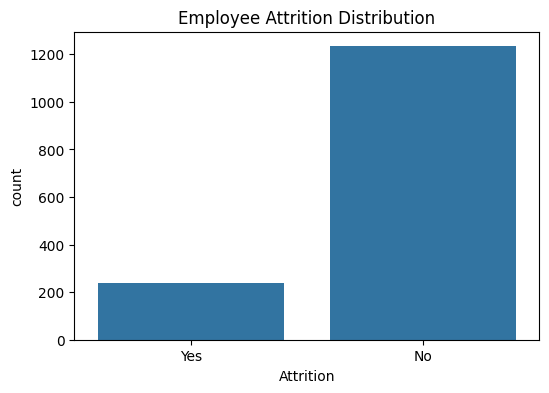

In [169]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Attrition")
plt.title("Employee Attrition Distribution")
plt.show()

## 4. Data Cleaning

In [170]:
print("Total missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Total missing values: 0
Duplicate rows: 0


No missing values and no duplicate rows were found.

The following constant/identifier columns are removed because they do not provide useful predictive information:

- `EmployeeCount`
- `EmployeeNumber`
- `Over18`
- `StandardHours`

In [171]:
unnecessary_columns = [
    "EmployeeCount",
    "EmployeeNumber",
    "Over18",
    "StandardHours"
]

df = df.drop(columns=unnecessary_columns)

print("Shape after removing unnecessary columns:", df.shape)

Shape after removing unnecessary columns: (1470, 31)


## 5. Exploratory Data Analysis

In [172]:
categorical_columns = df.select_dtypes(include="object").columns.tolist()
numerical_columns = df.select_dtypes(exclude="object").columns.tolist()

print("Categorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numerical_columns)

Categorical columns:
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Numerical columns:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


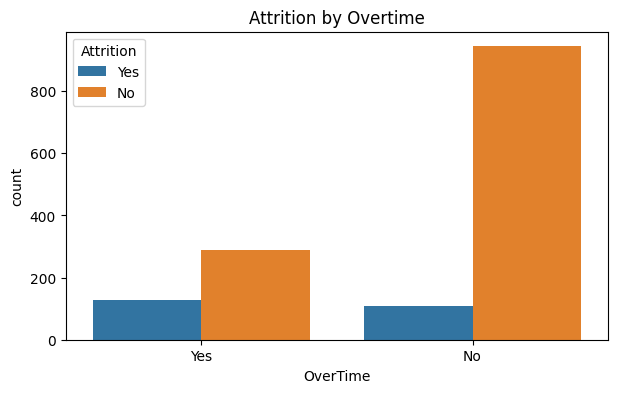

In [173]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="OverTime", hue="Attrition")
plt.title("Attrition by Overtime")
plt.show()

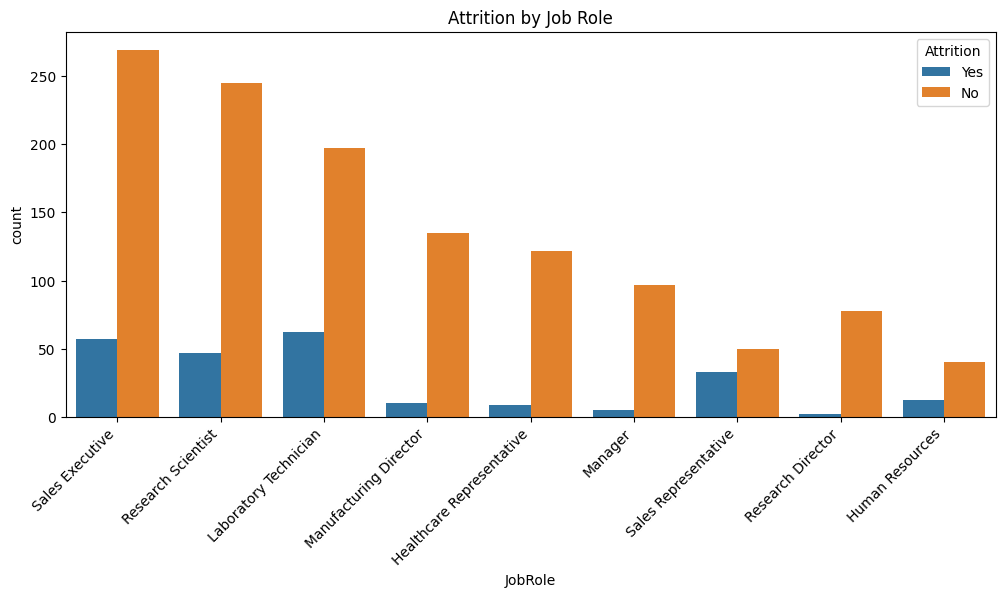

In [174]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x="JobRole", hue="Attrition")
plt.xticks(rotation=45, ha="right")
plt.title("Attrition by Job Role")
plt.show()

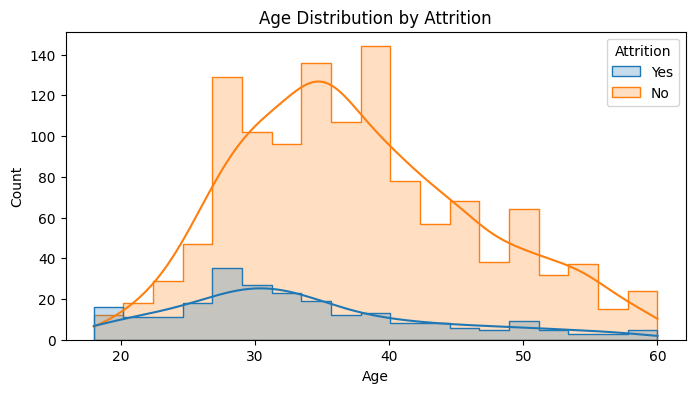

In [175]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="Age", hue="Attrition", kde=True, element="step")
plt.title("Age Distribution by Attrition")
plt.show()

## 6. Data Preprocessing

In [176]:
df["Attrition"] = df["Attrition"].astype(str).str.strip()

X = df.drop("Attrition", axis=1)
y = df["Attrition"].copy()

y = y.map({"No": 0, "Yes": 1})

print("Target distribution:")
print(y.value_counts())

Target distribution:
Attrition
0    1233
1     237
Name: count, dtype: int64


In [196]:
X = pd.get_dummies(X, drop_first=True)

print("Shape after encoding:", X.shape)
print("Number of features:", X.shape[1])

feature_columns = X.columns.tolist()
joblib.dump(feature_columns, "feature_columns.pkl")

print("Feature columns saved:", len(feature_columns))




Shape after encoding: (1470, 44)
Number of features: 44
Feature columns saved: 44


## 7. Train/Test Split

In [178]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data: (1176, 44)
Testing data: (294, 44)

Training target distribution:
Attrition
0    986
1    190
Name: count, dtype: int64

Testing target distribution:
Attrition
0    247
1     47
Name: count, dtype: int64


In [198]:
X_test.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Male,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
1061,24,830,13,2,4,78,3,1,2,2033,7103,1,13,3,3,1,1,2,3,1,0,0,0,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False
891,44,1117,2,1,1,72,4,1,4,2011,19982,1,13,3,4,1,10,5,3,10,5,7,7,False,True,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False
456,31,688,7,3,3,44,2,3,4,11557,25291,9,21,4,3,1,10,3,2,5,4,0,1,False,True,False,True,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False
922,44,1199,4,2,3,92,4,5,1,19190,17477,1,14,3,4,2,26,4,2,25,9,14,13,False,True,True,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False
69,36,318,9,3,4,79,2,1,3,3388,21777,0,17,3,1,1,2,0,2,1,0,0,0,False,True,True,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,True,False,True


In [199]:
y_test.head()

1061    0
891     0
456     0
922     0
69      1
Name: Attrition, dtype: int64

## 8. Feature Scaling

In [179]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, "scaler.pkl")

print("Training data after scaling:", X_train_scaled.shape)
print("Testing data after scaling:", X_test_scaled.shape)

Training data after scaling: (1176, 44)
Testing data after scaling: (294, 44)


## 9. Baseline ANN

In [180]:
baseline_model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

baseline_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 64)             │         2,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,993 (19.50 KB)

 Trainable params: 4,993 (19.50 KB)

 Non-trainable params: 0 (0.00 B)

In [181]:
baseline_history = baseline_model.fit(
    X_train_scaled, y_train,
    validation_split=0.20,
    epochs=50,
    batch_size=32,
    verbose=1
)

baseline_loss, baseline_accuracy = baseline_model.evaluate(
    X_test_scaled, y_test, verbose=0
)

print("Baseline Test Loss:", baseline_loss)
print("Baseline Test Accuracy:", baseline_accuracy)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.6894 - loss: 0.5993 - val_accuracy: 0.8305 - val_loss: 0.4876
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8404 - loss: 0.4264 - val_accuracy: 0.8305 - val_loss: 0.4334
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8457 - loss: 0.3845 - val_accuracy: 0.8475 - val_loss: 0.3999
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8543 - loss: 0.3541 - val_accuracy: 0.8602 - val_loss: 0.3800
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8702 - loss: 0.3292 - val_accuracy: 0.8602 - val_loss: 0.3586
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8755 - loss: 0.3074 - val_accuracy: 0.8686 - val_loss: 0.3403
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8926 - loss: 0.2874 - val_accuracy: 0.8559 - val_loss: 0.3325
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9021 - loss: 0.2712 - val_accuracy: 0.8686 - val_l

## 10. ANN Experimentation

A compact experiment is used to satisfy the assignment requirement to experiment with hidden layers, neurons, batch size and epochs. The goal is to improve the model without making the project unnecessarily long.

In [182]:
experiment_model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

experiment_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

experiment_history = experiment_model.fit(
    X_train_scaled, y_train,
    validation_split=0.20,
    epochs=50,
    batch_size=32,
    verbose=1
)

experiment_loss, experiment_accuracy = experiment_model.evaluate(
    X_test_scaled, y_test, verbose=0
)

print("Experiment Test Loss:", experiment_loss)
print("Experiment Test Accuracy:", experiment_accuracy)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.8213 - loss: 0.4736 - val_accuracy: 0.8305 - val_loss: 0.4250
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8489 - loss: 0.3632 - val_accuracy: 0.8390 - val_loss: 0.3741
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8702 - loss: 0.3110 - val_accuracy: 0.8686 - val_loss: 0.3426
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8926 - loss: 0.2659 - val_accuracy: 0.8814 - val_loss: 0.3361
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9096 - loss: 0.2348 - val_accuracy: 0.8898 - val_loss: 0.3230
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9191 - loss: 0.2013 - val_accuracy: 0.8898 - val_loss: 0.3254
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9351 - loss: 0.1703 - val_accuracy: 0.8898 - val_loss: 0.3421
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9489 - loss: 0.1417 - val_accuracy: 0.8898 - val_

## 11. Overfitting Analysis

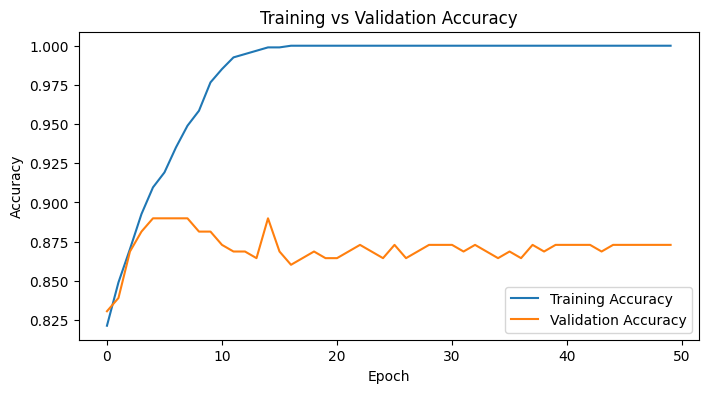

In [183]:
plt.figure(figsize=(8, 4))
plt.plot(experiment_history.history["accuracy"], label="Training Accuracy")
plt.plot(experiment_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

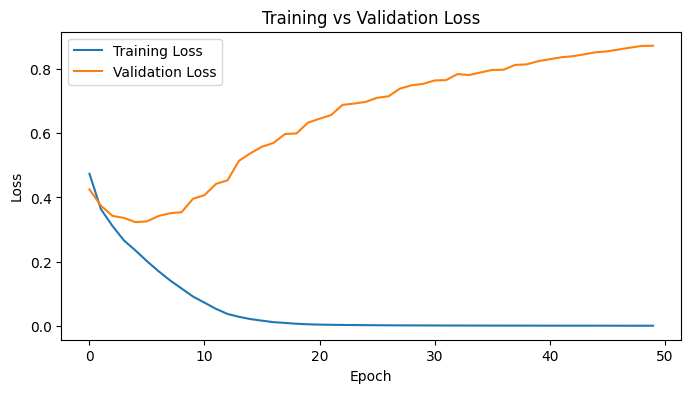

In [184]:
plt.figure(figsize=(8, 4))
plt.plot(experiment_history.history["loss"], label="Training Loss")
plt.plot(experiment_history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Observation

The training accuracy continued increasing while validation performance stopped improving. Validation loss also increased after the best validation period. This indicates overfitting, so Dropout and Early Stopping are applied.

## 12. Regularization — Dropout and Early Stopping

In [185]:
dropout_model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.30),
    Dense(64, activation="relu"),
    Dropout(0.20),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

dropout_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

dropout_history = dropout_model.fit(
    X_train_scaled, y_train,
    validation_split=0.20,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

dropout_loss, dropout_accuracy = dropout_model.evaluate(
    X_test_scaled, y_test, verbose=0
)

print("Dropout Test Loss:", dropout_loss)
print("Dropout Test Accuracy:", dropout_accuracy)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.7564 - loss: 0.5300 - val_accuracy: 0.8305 - val_loss: 0.4389
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8404 - loss: 0.4147 - val_accuracy: 0.8305 - val_loss: 0.3933
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8447 - loss: 0.3751 - val_accuracy: 0.8390 - val_loss: 0.3645
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8543 - loss: 0.3652 - val_accuracy: 0.8517 - val_loss: 0.3456
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8638 - loss: 0.3405 - val_accuracy: 0.8686 - val_loss: 0.3296
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8798 - loss: 0.3062 - val_accuracy: 0.8729 - val_loss: 0.3263
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8798 - loss: 0.2961 - val_accuracy: 0.8856 - val_loss: 0.3150
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8894 - loss: 0.2870 - val_accuracy: 0.8941 - v

## 13. Class Imbalance

In [186]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(
    zip(np.unique(y_train), class_weights)
)

print("Class weights:", class_weight_dict)

Class weights: {np.int64(0): np.float64(0.5963488843813387), np.int64(1): np.float64(3.094736842105263)}


The dataset contains many more `No Attrition` employees than `Attrition` employees. Class weighting gives the minority `Attrition` class greater importance during training.

## 14. Final Class-Weighted ANN

In [187]:
final_model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.30),
    Dense(64, activation="relu"),
    Dropout(0.20),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

final_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

final_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

final_history = final_model.fit(
    X_train_scaled, y_train,
    validation_split=0.20,
    epochs=50,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[final_early_stopping],
    verbose=1
)

final_loss, final_accuracy = final_model.evaluate(
    X_test_scaled, y_test, verbose=0
)

print("Final Test Loss:", final_loss)
print("Final Test Accuracy:", final_accuracy)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.5777 - loss: 0.6608 - val_accuracy: 0.6483 - val_loss: 0.6253
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6872 - loss: 0.5872 - val_accuracy: 0.7034 - val_loss: 0.5870
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7106 - loss: 0.5518 - val_accuracy: 0.7669 - val_loss: 0.5175
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7213 - loss: 0.5265 - val_accuracy: 0.8051 - val_loss: 0.4507
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7691 - loss: 0.4693 - val_accuracy: 0.7924 - val_loss: 0.4733
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7872 - loss: 0.4657 - val_accuracy: 0.8347 - val_loss: 0.3977
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8128 - loss: 0.4245 - val_accuracy: 0.8008 - val_loss: 0.4684
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8011 - loss: 0.4257 - val_accuracy: 0.8136 - val_

## 15. Final Evaluation

In [188]:
y_probability = final_model.predict(
    X_test_scaled, verbose=0
).ravel()

y_pred = (y_probability >= 0.5).astype(int)

print(classification_report(
    y_test,
    y_pred,
    target_names=["No Attrition", "Attrition"]
))

              precision    recall  f1-score   support

No Attrition       0.90      0.89      0.90       247
   Attrition       0.46      0.51      0.48        47

    accuracy                           0.83       294
   macro avg       0.68      0.70      0.69       294
weighted avg       0.83      0.83      0.83       294



Final Confusion Matrix:
[[219  28]
 [ 23  24]]


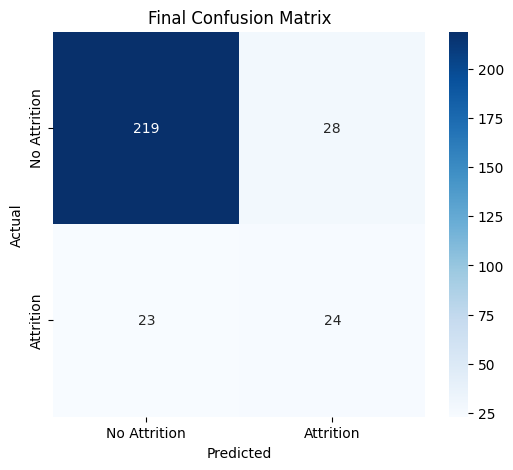

In [189]:
cm = confusion_matrix(y_test, y_pred)

print("Final Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["No Attrition", "Attrition"],
    yticklabels=["No Attrition", "Attrition"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Confusion Matrix")
plt.show()

In [190]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-Score :", f1_score(y_test, y_pred))

Accuracy : 0.826530612244898
Precision: 0.46153846153846156
Recall   : 0.5106382978723404
F1-Score : 0.48484848484848486


## 16. Model Comparison

In [191]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline ANN",
        "Experiment ANN",
        "Dropout ANN",
        "Final Class-Weighted ANN"
    ],
    "Test Accuracy": [
        baseline_accuracy,
        experiment_accuracy,
        dropout_accuracy,
        accuracy_score(y_test, y_pred)
    ]
})

comparison

,Model,Test Accuracy
0,Baseline ANN,0.833333
1,Experiment ANN,0.846939
2,Dropout ANN,0.870748
3,Final Class-Weighted ANN,0.826531


## 17. Final Conclusion

The ANN successfully learned patterns related to employee attrition.

Feature scaling helped the neural network train effectively, while experimentation with neurons and network structure helped identify a suitable architecture. The baseline model showed overfitting, so Dropout and Early Stopping were introduced to improve generalization.

The dataset was imbalanced, with substantially more `No Attrition` cases than `Attrition` cases. Class weighting increased the importance of the minority class and improved the model's ability to identify employees who actually leave.

For this HR business problem, accuracy alone is not sufficient. Attrition recall and F1-score are important because missing an employee who is actually going to leave can reduce the usefulness of the system.

The final class-weighted ANN is therefore selected based on its better balance between overall performance and detection of the minority Attrition class.

## 18. Save Final Model

In [192]:
final_model.save("employee_attrition_ann.keras")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(feature_columns, "feature_columns.pkl")

print("Saved:")
print("1. employee_attrition_ann.keras")
print("2. scaler.pkl")
print("3. feature_columns.pkl")

Saved:
1. employee_attrition_ann.keras
2. scaler.pkl
3. feature_columns.pkl


### Final Files

```text
employee_attrition.ipynb
employee_attrition_ann.keras
scaler.pkl
feature_columns.pkl
```

These files are ready for the next stage: `predict.py` and the Flask application.